# Part 1 - Product Recognition System (Team Work)

This section contains the existing feature extraction and product matching system developed by the team.

In [1]:
from pathlib import Path
import pickle
import numpy as np
import torch
import torchvision.models as models
import torchvision.transforms as T
from PIL import Image

class RPCFeatureExtractor:
    def __init__(self, device=None):
        
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'

        # Load pre-trained ResNet50 and remove classification head
        resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        self.model = torch.nn.Sequential(*list(resnet.children())[:-1]).to(self.device)
        self.model.eval()

        # Define image preprocessing transformation
        self.transform = T.Compose([
            T.Resize((224, 224)),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def _extract_single(self, img_path):
        img = Image.open(img_path).convert('RGB')
        tensor = self.transform(img).unsqueeze(0).to(self.device)
        with torch.no_grad():
            vec = self.model(tensor).squeeze()
        return vec.cpu().numpy()

    def process_catalog_item(self, item_name, input_dir, output_dir="vectors"):
        input_path = Path(input_dir)
        output_path = Path(output_dir)
        output_path.mkdir(parents=True, exist_ok=True)

        valid_exts = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
        images = [p for p in input_path.iterdir() if p.suffix.lower() in valid_exts]

        if not images:
            raise FileNotFoundError(f"No valid images found in {input_dir}")

        features = [self._extract_single(img) for img in images]
        matrix = np.array(features)

        payload = {
            'item_id': item_name,
            'features': matrix,
            'num_samples': len(features)
        }

        save_file = output_path / f"{item_name}.pkl"
        with open(save_file, 'wb') as f:
            pickle.dump(payload, f)

        return save_file, matrix.shape


# Usage Example:
if __name__ == "__main__":
    extractor = RPCFeatureExtractor()
    print(f"Backend initialized on: {extractor.device}")

Backend initialized on: cpu


In [2]:
import os
from pathlib import Path
from rembg import remove
from PIL import Image, ImageEnhance

def preprocess_image(img_path, save_path, target_dim=500):
    # Load image and clear background
    raw_img = Image.open(img_path).convert("RGBA")
    clean_obj = remove(raw_img)

    # Crop to subject bounds
    crop_box = clean_obj.getbbox()
    if crop_box:
        clean_obj = clean_obj.crop(crop_box)

    # Simple contrast & brightness tweaks
    clean_obj = ImageEnhance.Contrast(clean_obj).enhance(1.15)
    clean_obj = ImageEnhance.Brightness(clean_obj).enhance(1.10)

    # Setup white canvas
    bg = Image.new("RGBA", (target_dim, target_dim), "WHITE")

    # Scale image to fit with padding
    max_dim = int(target_dim * 0.85)
    clean_obj.thumbnail((max_dim, max_dim), Image.Resampling.LANCZOS)

    # Center placement
    pos_x = (target_dim - clean_obj.width) // 2
    pos_y = (target_dim - clean_obj.height) // 2
    bg.paste(clean_obj, (pos_x, pos_y), clean_obj)

    # Save output as JPEG
    res = bg.convert("RGB")
    res.save(save_path, "JPEG", quality=95)


def run_pipeline(data_dir="data", out_dir="clean_data"):
    input_base = Path(data_dir)
    output_base = Path(out_dir)
    
    allowed_formats = {'.jpg', '.jpeg', '.png', '.webp'}

    for folder in input_base.iterdir():
        if not folder.is_dir():
            continue
            
        target_dir = output_base / folder.name
        target_dir.mkdir(parents=True, exist_ok=True)
        
        print(f"Working on: {folder.name}")
        
        for file in folder.iterdir():
            if file.suffix.lower() in allowed_formats:
                output_file = target_dir / f"{file.stem}_clean.jpg"
                try:
                    preprocess_image(file, output_file)
                    print(f"Done: {file.name}")
                except Exception as e:
                    print(f"Error processing {file.name}: {e}")

PREPROCESS_IMAGES = False

if PREPROCESS_IMAGES:
    print("Processing images...")
    run_pipeline()
    print("Done processing all images.")

else:
    if not Path("clean_data").exists():
        raise FileNotFoundError(
            "clean_data is missing. Set PREPROCESS_IMAGES = True once."
        )

    print("Image preprocessing skipped — clean_data is ready.")

C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Image preprocessing skipped — clean_data is ready.


In [3]:
from pathlib import Path
from PIL import Image
import pickle
import numpy as np
import torch

# True فقط عند بناء الـvectors من جديد
BUILD_VECTORS = False

clean_data_root = Path("clean_data")
vectors_dir = Path("vectors")
vectors_dir.mkdir(exist_ok=True)

rotation_angles = [
    -90, -60, -45, -30, -15,
    0,
    15, 30, 45, 60, 90, 180
]

valid_extensions = {
    ".jpg", ".jpeg", ".png", ".bmp", ".webp"
}

if BUILD_VECTORS:
    # Remove old vector files
    for old_file in vectors_dir.glob("*.pkl"):
        old_file.unlink()

    for product_folder in sorted(clean_data_root.iterdir()):
        if not product_folder.is_dir():
            continue

        features = []

        image_paths = [
            path for path in product_folder.iterdir()
            if path.suffix.lower() in valid_extensions
        ]

        for image_path in image_paths:
            image = Image.open(image_path).convert("RGB")

            for angle in rotation_angles:
                rotated_image = image.rotate(
                    angle,
                    resample=Image.Resampling.BICUBIC,
                    expand=True,
                    fillcolor="white"
                )

                tensor = (
                    extractor.transform(rotated_image)
                    .unsqueeze(0)
                    .to(extractor.device)
                )

                with torch.no_grad():
                    vector = extractor.model(tensor).squeeze()

                features.append(vector.cpu().numpy())

        matrix = np.array(features)

        item_name = f"{product_folder.name}_vector"

        payload = {
            "item_id": item_name,
            "features": matrix,
            "num_samples": len(features)
        }

        save_path = vectors_dir / f"{item_name}.pkl"

        with open(save_path, "wb") as file:
            pickle.dump(payload, file)

        print(
            f"Processed: {product_folder.name} | "
            f"Vectors: {len(features)}"
        )

    print("Rotation-augmented vectors created successfully.")

else:
    vector_files = list(vectors_dir.glob("*.pkl"))

    if not vector_files:
        raise FileNotFoundError(
            "No vectors found. Set BUILD_VECTORS = True once."
        )

    print("Vector generation skipped — existing vectors are ready.")

Vector generation skipped — existing vectors are ready.


In [4]:
import pickle
import numpy as np
import torch
from pathlib import Path
from PIL import Image


class RPCProductMatcher:
    def __init__(self, feature_extractor, vectors_dir="vectors"):
        self.extractor = feature_extractor
        self.vectors_dir = Path(vectors_dir)

        self.query_angles = [
            -90, -60, -45, -30, -15,
            0,
            15, 30, 45, 60, 90, 180
        ]

        self.catalog = self._load_catalog()

    def _load_catalog(self):
        catalog = {}

        for pkl_path in self.vectors_dir.glob("*.pkl"):
            with open(pkl_path, "rb") as file:
                data = pickle.load(file)

            features = data["features"]

            features = features / np.clip(
                np.linalg.norm(
                    features,
                    axis=1,
                    keepdims=True
                ),
                1e-12,
                None
            )

            catalog[data["item_id"]] = features

        return catalog

    def _extract_query_angles(self, query_img_path):
        image = Image.open(query_img_path).convert("RGB")
        query_features = []

        for angle in self.query_angles:
            rotated = image.rotate(
                angle,
                resample=Image.Resampling.BICUBIC,
                expand=True,
                fillcolor="white"
            )

            tensor = (
                self.extractor.transform(rotated)
                .unsqueeze(0)
                .to(self.extractor.device)
            )

            with torch.no_grad():
                vector = (
                    self.extractor.model(tensor)
                    .squeeze()
                    .cpu()
                    .numpy()
                )

            vector = vector / max(
                np.linalg.norm(vector),
                1e-12
            )

            query_features.append(vector)

        return np.array(query_features)

    def predict_product(
        self,
        query_img_path,
        min_similarity=0.55,
        min_margin=0.02
    ):
        query_features = self._extract_query_angles(
            query_img_path
        )

        product_scores = {}

        for item_id, reference_features in self.catalog.items():
            similarities = (
                query_features @ reference_features.T
            )

            # Find the best reference match for each query angle
            best_per_angle = similarities.max(axis=1)

            # Ignore the weakest 25% of the query angles
            keep_count = max(
                3,
                int(np.ceil(len(best_per_angle) * 0.75))
            )

            strongest_angles = np.sort(
                best_per_angle
            )[-keep_count:]

            product_scores[item_id] = float(
                strongest_angles.mean()
            )

        ranking = sorted(
            product_scores.items(),
            key=lambda item: item[1],
            reverse=True
        )

        best_item, best_score = ranking[0]

        second_score = (
            ranking[1][1]
            if len(ranking) > 1
            else 0.0
        )

        margin = best_score - second_score

        # Return unknown instead of guessing when the result is unclear
        if (
            best_score < min_similarity
            or margin < min_margin
        ):
            predicted_item = "unknown"
        else:
            predicted_item = best_item

        print(
            f"Best match: {best_item.replace('_vector', '')} | "
            f"Similarity: {best_score:.2%} | "
            f"Margin: {margin:.2%}"
        )

        return predicted_item, best_score, product_scores


matcher = RPCProductMatcher(extractor)

print(
    f"Loaded {len(matcher.catalog)} products into memory."
)

Loaded 14 products into memory.


# Part 2 - YOLO Product Detection (Abdullah's Work)

This section adds product localization using YOLO to detect each product with a bounding box.

In [5]:
from pathlib import Path

folders = [
    "yolo_data/images/train",
    "yolo_data/images/val",
    "yolo_data/labels/train",
    "yolo_data/labels/val"
]

for folder in folders:
    Path(folder).mkdir(parents=True, exist_ok=True)

print("YOLO dataset folders created!")

YOLO dataset folders created!


## Dataset Annotation Function

This function is used to manually draw bounding boxes and convert them to YOLO label format

In [6]:
import cv2
import shutil
from pathlib import Path

def annotate_all_images(limit=None):
    image_paths = sorted([
        p for p in Path("test_p").iterdir()
        if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
    ])

    processed = 0

    for index, image_path in enumerate(image_paths):
        if limit is not None and processed >= limit:
            break

        # Skip images already annotated
        already_done = any(
            (Path(f"yolo_data/labels/{split}") / f"{image_path.stem}.txt").exists()
            for split in ["train", "val"]
        )

        if already_done:
            continue

        # 80% training and 20% validation
        split = "val" if index % 5 == 0 else "train"

        image = cv2.imread(str(image_path))

        if image is None:
            print("Could not open:", image_path.name)
            continue

        img_h, img_w = image.shape[:2]

        scale = min(1200 / img_w, 700 / img_h, 1.0)

        display_image = cv2.resize(
            image,
            (int(img_w * scale), int(img_h * scale))
        )

        boxes = cv2.selectROIs(
            f"{image_path.name} - Select products, then press ESC",
            display_image,
            showCrosshair=True,
            fromCenter=False
        )

        cv2.destroyAllWindows()

        if len(boxes) == 0:
            print("Skipped:", image_path.name)
            continue

        dest_image = Path(f"yolo_data/images/{split}") / image_path.name
        dest_label = Path(f"yolo_data/labels/{split}") / f"{image_path.stem}.txt"

        shutil.copy2(image_path, dest_image)

        yolo_lines = []

        for x, y, w, h in boxes:
            x = x / scale
            y = y / scale
            w = w / scale
            h = h / scale

            x_center = (x + w / 2) / img_w
            y_center = (y + h / 2) / img_h
            norm_w = w / img_w
            norm_h = h / img_h

            yolo_lines.append(
                f"0 {x_center:.6f} {y_center:.6f} "
                f"{norm_w:.6f} {norm_h:.6f}"
            )

        dest_label.write_text("\n".join(yolo_lines), encoding="utf-8")

        processed += 1

        print(
            f"Saved: {image_path.name} | "
            f"{split} | Products: {len(boxes)}"
        )

## Manual Dataset Annotation

The following section prepares the manually annotated images for the YOLO dataset.

- Training images are used to train the detector.
- Validation images are used to evaluate the detector during training.

Manual annotation is disabled by default. Set `RUN_MANUAL_ANNOTATION = True` only when rebuilding the YOLO labels.

## YOLO Dataset Configuration

Create the data.yaml file that defines the training and validation paths and the product class

In [7]:
from pathlib import Path

project_root = Path.cwd()
yolo_root = project_root / "yolo_data"

yaml_content = f"""
path: {yolo_root.as_posix()}
train: images/train
val: images/val

names:
  0: product
"""

yaml_path = yolo_root / "data.yaml"
yaml_path.write_text(yaml_content.strip(), encoding="utf-8")

print("data.yaml created!")
print()
print(yaml_path.read_text())

data.yaml created!

path: c:/Users/hp/OneDrive/ط³ط·ط­ ط§ظ„ظ…ظƒطھط¨/PROJECT2/PROJECT2/yolo_data
train: images/train
val: images/val

names:
  0: product


## Dataset Validation

Check that every training and validation image has a matching YOLO label file

In [8]:
from pathlib import Path

for split in ["train", "val"]:

    image_dir = Path(f"yolo_data/images/{split}")
    label_dir = Path(f"yolo_data/labels/{split}")

    images = [
     p for p in image_dir.iterdir()
     if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
    ]
    labels = list(label_dir.glob("*.txt"))

    print(f"\n--- {split.upper()} ---")
    print("Images:", len(images))
    print("Labels:", len(labels))

    image_names = {x.stem for x in images}
    label_names = {x.stem for x in labels}

    missing_labels = image_names - label_names
    missing_images = label_names - image_names

    if not missing_labels and not missing_images:
        print("All images have matching labels ✅")
    else:
        print("Images without labels:", missing_labels)
        print("Labels without images:", missing_images)


--- TRAIN ---
Images: 28
Labels: 28
All images have matching labels ✅

--- VAL ---
Images: 7
Labels: 7
All images have matching labels ✅


## YOLO Model Training

Train YOLO11n on the prepared product dataset for 100 epochs

In [9]:
from pathlib import Path
import shutil
from ultralytics import YOLO

TRAIN_YOLO = False

ready_model_path = Path("product_detector.pt")

if TRAIN_YOLO:
    model2 = YOLO("yolo11n.pt")

    results2 = model2.train(
        data="yolo_data/data.yaml",
        epochs=100,
        imgsz=640,
        batch=2,
        device="cpu",
        workers=0,
        project="runs/detect",
        name="product_detector_100",
        exist_ok=True
    )

    best_path = Path(model2.trainer.best)
    shutil.copy2(best_path, ready_model_path)

    print("Training completed and model saved:", ready_model_path)

else:
    if not ready_model_path.exists():
        raise FileNotFoundError(
            "product_detector.pt is missing."
        )

    print("Training skipped — pretrained model is ready.")

Training skipped — pretrained model is ready.


## Load the Trained YOLO Model

Find and load the best model weights generated after training

In [10]:
from pathlib import Path

ready_model_path = Path("product_detector.pt")

if not ready_model_path.exists():
    raise FileNotFoundError("product_detector.pt is missing.")

model_files = [ready_model_path]

print("Found:", len(model_files))
print(model_files[0])

Found: 1
product_detector.pt


In [11]:
ready_model = Path("product_detector.pt")

print("Ready model:", ready_model)
print("Size:", ready_model.stat().st_size, "bytes")

Ready model: product_detector.pt
Size: 5465306 bytes


In [12]:
from ultralytics import YOLO

trained_model_100 = YOLO(str(model_files[0]))

print("Trained YOLO model loaded successfully.")

Trained YOLO model loaded successfully.


## Product Detection Test

Test the trained YOLO model on an image containing multiple overlapping products

## Final Integration - YOLO + Product Matcher

YOLO detects each product, then each detected region is cropped and sent to the existing RPCProductMatcher for product identification

Products detected: 3
Best match: 010 | Similarity: 89.76% | Margin: 9.22%
Product 1: 010 | 89.76%
Best match: 009 | Similarity: 90.21% | Margin: 15.73%
Product 2: 009 | 90.21%
Best match: 001 | Similarity: 85.22% | Margin: 20.24%
Product 3: 001 | 85.22%


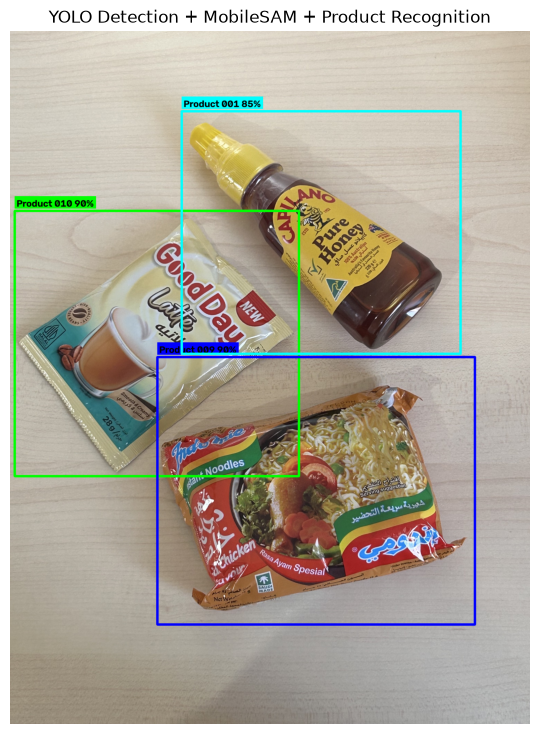

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import SAM

image_path = "test_p/IMG_6267.jpg"
image = cv2.imread(image_path)

if image is None:
    raise FileNotFoundError(f"Image not found: {image_path}")

img_h, img_w = image.shape[:2]

# 1. Detect all products using YOLO
detection_results = trained_model_100.predict(
    source=image_path,
    conf=0.40,
    iou=0.30,
    save=False,
    verbose=False
)

detected_boxes = detection_results[0].boxes

print("Products detected:", len(detected_boxes))

if len(detected_boxes) == 0:
    print("No products detected.")

else:
    # 2. Send YOLO boxes to MobileSAM
    box_prompts = detected_boxes.xyxy.cpu().numpy().tolist()

    sam_model = SAM("mobile_sam.pt")

    segmentation_results = sam_model.predict(
        source=image_path,
        bboxes=box_prompts,
        device="cpu",
        verbose=False
    )

    masks = segmentation_results[0].masks.data.cpu().numpy()

    crop_dir = Path("final_crops")
    crop_dir.mkdir(exist_ok=True)

    # Remove old generated crops
    for old_crop in crop_dir.glob("product_*.png"):
        old_crop.unlink()

    # Different colors for products (BGR)
    # Red is not included because it is reserved for warnings
    colors = [
        (0, 255, 0),       # Green
        (255, 0, 0),       # Blue
        (255, 255, 0),     # Cyan
        (0, 255, 255),     # Yellow
        (255, 128, 0),     # Light blue
        (128, 255, 0),     # Turquoise
        (255, 255, 128),   # Light cyan
        (128, 128, 0)      # Teal
    ]

    for i, (box, mask) in enumerate(
        zip(detected_boxes, masks)
    ):
        # Select a different color for each product
        color = colors[i % len(colors)]

        x1, y1, x2, y2 = (
            box.xyxy[0].cpu().numpy().astype(int)
        )

        # Resize the MobileSAM mask
        mask = cv2.resize(
            mask,
            (img_w, img_h),
            interpolation=cv2.INTER_NEAREST
        ) > 0.5

        # Keep only the selected product
        isolated = np.full_like(image, 255)
        isolated[mask] = image[mask]

        ys, xs = np.where(mask)

        if len(xs) == 0 or len(ys) == 0:
            print(f"Could not isolate product {i + 1}")
            continue

        crop = isolated[
            ys.min():ys.max() + 1,
            xs.min():xs.max() + 1
        ]

        crop_path = crop_dir / f"product_{i + 1}.png"
        cv2.imwrite(str(crop_path), crop)

        # 3. Identify the isolated product
        predicted_item, confidence, all_scores = (
            matcher.predict_product(str(crop_path))
        )

        display_name = predicted_item.replace(
            "_vector",
            ""
        )

        print(
            f"Product {i + 1}: "
            f"{display_name} | "
            f"{confidence:.2%}"
        )

        # Draw the product box
        cv2.rectangle(
            image,
            (x1, y1),
            (x2, y2),
            color,
            8
        )

        # Prepare the label
        label = (
            f"Product {display_name} "
            f"{confidence:.0%}"
        )

        font_scale = 1.2
        font_thickness = 3

        (text_width, text_height), baseline = (
            cv2.getTextSize(
                label,
                cv2.FONT_HERSHEY_SIMPLEX,
                font_scale,
                font_thickness
            )
        )

        label_y = max(
            y1 - 10,
            text_height + 15
        )

        # Colored background for the label
        cv2.rectangle(
            image,
            (
                x1,
                label_y - text_height - 12
            ),
            (
                x1 + text_width + 14,
                label_y + baseline
            ),
            color,
            -1
        )

        # Black text for readability
        cv2.putText(
            image,
            label,
            (x1 + 7, label_y - 5),
            cv2.FONT_HERSHEY_SIMPLEX,
            font_scale,
            (0, 0, 0),
            font_thickness
        )

    # Save and display the final result
    cv2.imwrite("final_result.jpg", image)

    image_rgb = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    plt.figure(figsize=(12, 9))
    plt.imshow(image_rgb)
    plt.axis("off")
    plt.title(
        "YOLO Detection + MobileSAM + "
        "Product Recognition"
    )
    plt.show()